## Chunking Strategy

Looking at the structure of my data I can clearly see that it is structured, where each paragraph represents a page and each line inside the paragraph represents a section in the page, and each sentence inside line represents a certain element inside of the section, so for maintaining context and semantics I’ve chosen to start experimenting using RecursiveCharacterTextSplitter from Langchain. This chunking strategy respects the structure and the semantics of my data 

The following image is an example of the output of applying recursive Character Text Splitter to the data extracted from the cloud consulting and migration page with a chunk_size = 2000

You can see that the chunking strategy respects the structure of the data
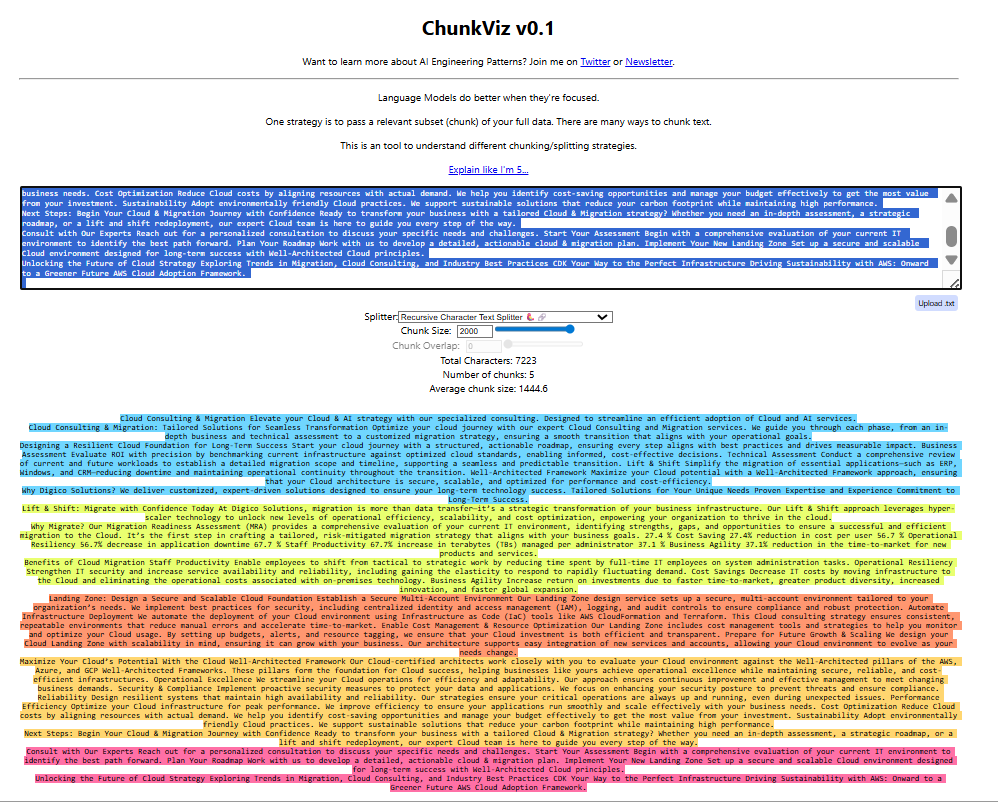

In [96]:
import json
import nltk
from nltk import word_tokenize

from langchain.text_splitter import RecursiveCharacterTextSplitter
import re
import contractions

The chunking code in the next cell works as follows : 
## Recursive Splitting

1. **Priority-based splitting**: The algorithm tries each separator in order:
   - First tries `"\n\n"` (paragraph breaks)
   - If chunks are still too big, tries `"\n"` (line breaks)
   - Then `". "` (sentence boundaries)
   - Then `" "` (word boundaries)
   - Finally `""` (character-by-character if needed)

2. **Recursive process**: For each chunk that exceeds `chunk_size`:
   - Attempt to split using the first separator
   - If that doesn't create small enough chunks, move to the next separator
   - Continue recursively until all chunks are appropriately sized



In [97]:

# def chunk_text_file(file_path, chunk_size=500, chunk_overlap=50):
#     """
#     Chunk a text file with paragraphs separated by empty lines
    
#     Args:
#         file_path (str): Path to the text file
#         chunk_size (int): Target size for each chunk
    
#     Returns:
#         list: List of text chunks
#     """
    
#     # Read the file content
#     with open(file_path, 'r', encoding='utf-8') as file:
#         text = file.read()
    
#     # Initialize the text splitter with appropriate parameters
#     text_splitter = RecursiveCharacterTextSplitter(
#         chunk_size=chunk_size,
#         chunk_overlap=chunk_overlap,
#         length_function=len,
#         separators=["\n\n", "\n", ". ", " ", ""]  # Priority: paragraphs, lines, sentences, words
#     )
    
#     # Split the text into chunks
#     chunks = text_splitter.split_text(text)
    
#     # Display information about the chunks
#     print(f"Original text length: {len(text)} characters")
#     print(f"Number of chunks created: {len(chunks)}")
#     print(f"Average chunk length: {sum(len(chunk) for chunk in chunks) / len(chunks):.0f} characters")    
    
#     return chunks

# def save_chunks_to_json(chunks, output_file="chunks.json"):
#     """
#     Save chunks to a JSON file with metadata
    
#     Args:
#         chunks (list): List of text chunks
#         output_file (str): Path to output JSON file
#     """
#     # Prepare data for JSON
#     chunks_data = []
#     for i, chunk in enumerate(chunks):
#         chunk_info = {
#             "chunk_id": i + 1,
#             "text": chunk,
#             # "word_count": len(chunk.split()),
#             # "char_count": len(chunk)
#         }
#         chunks_data.append(chunk_info)
    
#     # Create summary information
#     summary = {
#         "total_chunks": len(chunks),
#         # "total_characters": sum(chunk['char_count'] for chunk in chunks_data),
#         # "total_words": sum(chunk['word_count'] for chunk in chunks_data),
#         # "average_chunk_length": sum(chunk['char_count'] for chunk in chunks_data) / len(chunks),
#         # "average_word_count": sum(chunk['word_count'] for chunk in chunks_data) / len(chunks)
#     }
    
#     # Combine data and summary
#     output_data = {
#         "chunks": chunks_data
#     }
    
#     # Save to JSON file
#     with open(output_file, 'w', encoding='utf-8') as f:
#         json.dump(output_data, f, indent=2, ensure_ascii=False)
    
#     print(f"\nChunks saved to {output_file}")

# # Example usage
# if __name__ == "__main__":
#     # Replace with your file path
#     file_path = "../Scraping_Digico_Website/scraped_data/cleaned_text_content.txt"
#     output_json = "./data/chunks.json"
    
#     # Chunk with recommended parameters
#     chunks = chunk_text_file(
#         file_path=file_path,
#         chunk_size=2500,    # Target chunk size
#     )
    
#     # Save chunks to JSON file
#     save_chunks_to_json(chunks, output_json)

In [98]:
# fix length splitting
import json
from langchain.text_splitter import TokenTextSplitter


def chunk_text_file(file_path, chunk_size=512, chunk_overlap=50, encoding_name="cl100k_base"):
    """
    Chunk a text file into fixed-size chunks based on tokens using LangChain

    Args:
        file_path (str): Path to the text file
        chunk_size (int): Number of tokens per chunk
        chunk_overlap (int): Number of tokens to overlap between chunks
        encoding_name (str): Tokenizer encoding (cl100k_base works with OpenAI models)

    Returns:
        list: List of text chunks
    """
    # Read the file content
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Initialize LangChain TokenTextSplitter
    text_splitter = TokenTextSplitter(
        encoding_name=encoding_name,
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )

    # Split text into chunks
    chunks = text_splitter.split_text(text)

    print(f"Original length: {len(text.split())} words (approx)")
    print(f"Number of chunks created: {len(chunks)}")
    return chunks


def save_chunks_to_json(chunks, output_file="chunks.json"):
    """
    Save chunks to a JSON file with metadata
    """
    chunks_data = []
    for i, chunk in enumerate(chunks):
        chunk_info = {
            "chunk_id": i + 1,
            "text": chunk,
            "token_count": len(chunk.split())  # rough token count, not exact
        }
        chunks_data.append(chunk_info)

    output_data = {"chunks": chunks_data}

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(output_data, f, indent=2, ensure_ascii=False)

    print(f"\nChunks saved to {output_file}")


if __name__ == "__main__":
    file_path = "../Scraping_Digico_Website/scraped_data/cleaned_text_content.txt"
    output_json = "./data/chunks.json"

    # Fixed-size token chunking
    chunks = chunk_text_file(file_path, chunk_size=512, chunk_overlap=50)
    save_chunks_to_json(chunks, output_json)


Original length: 84155 words (approx)
Number of chunks created: 227

Chunks saved to ./data/chunks.json


In [99]:
from nltk.corpus import stopwords

# Load standard English stopwords
stop_words = set(stopwords.words("english"))

# Keep negation-related words
negation_words = {"not", "no", "nor", "never", "very", "too", "just", "only", "even", "almost", "but", "however", "although", "though", "yet", "before", "after",  "until",  "since",  "because",  "if",  "unless",  "while", "all",  "any",  "few", "most", "some", "many", "several", "more", "less", "can", "could", "should", "would", "may", "might", "must", "shall", "not", "no", "nor", "never", "none", "nothing", "neither", "nowhere", "hardly", "scarcely", "barely"}
stop_words = stop_words - negation_words

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words]
    return " ".join(filtered)


In [100]:
from pathlib import Path

# Input/output paths
input_path = Path("./data/chunks.json")
output_path = Path("./data/chunks_cleaned.json")

# Replacement rules
replacements = [
    ('\n\n', ' '),
    ('\n', ' '),
    ('\"', ''),
    ('. ', ' '),
    (', ', ' '),
    ('; ', ' '),
    (': ', ' ')
]

def clean_text(text):
    cleaned = text

    # Expand contractions first (isn't -> is not, don't -> do not, etc.)
    cleaned = contractions.fix(cleaned)
    
    # Apply simple replacements
    for old, new in replacements:
        cleaned = cleaned.replace(old, new)

    # If line starts with ". " remove it
    cleaned = re.sub(r'^\ \s+', '', cleaned)

    # Normalize spaces (optional)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    # lowercase the cleaned text
    cleaned = cleaned.lower()

    cleaned = remove_stopwords(cleaned)

    return cleaned

def main():
    # Load original file
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    cleaned_chunks = {"chunks": []}

    for chunk in data.get("chunks", []):
        original_text = chunk.get("text", "")
        cleaned_text = clean_text(original_text)

        cleaned_chunks["chunks"].append({
            "chunk_id": chunk.get("chunk_id"),
            "original_text": original_text,
            "cleaned_text": cleaned_text
        })

    # Save new file
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(cleaned_chunks, f, ensure_ascii=False, indent=2)
    print(f"The output is saved to {output_path}")

if __name__ == "__main__":
    main()


The output is saved to data\chunks_cleaned.json


In [101]:
# counting the number of words in the cleaned chunks

# Load the JSON file
with open('./data/chunks_cleaned.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# Count and print word counts for each cleaned_text
for chunk in data['chunks']:
    word_count = len(chunk['cleaned_text'].split())
    print(f"Chunk {chunk['chunk_id']}: {word_count} words")

Chunk 1: 292 words
Chunk 2: 286 words
Chunk 3: 276 words
Chunk 4: 287 words
Chunk 5: 287 words
Chunk 6: 301 words
Chunk 7: 297 words
Chunk 8: 316 words
Chunk 9: 288 words
Chunk 10: 290 words
Chunk 11: 296 words
Chunk 12: 313 words
Chunk 13: 306 words
Chunk 14: 336 words
Chunk 15: 330 words
Chunk 16: 348 words
Chunk 17: 326 words
Chunk 18: 327 words
Chunk 19: 330 words
Chunk 20: 337 words
Chunk 21: 327 words
Chunk 22: 330 words
Chunk 23: 335 words
Chunk 24: 316 words
Chunk 25: 303 words
Chunk 26: 314 words
Chunk 27: 313 words
Chunk 28: 358 words
Chunk 29: 329 words
Chunk 30: 314 words
Chunk 31: 338 words
Chunk 32: 342 words
Chunk 33: 339 words
Chunk 34: 327 words
Chunk 35: 314 words
Chunk 36: 321 words
Chunk 37: 304 words
Chunk 38: 291 words
Chunk 39: 271 words
Chunk 40: 279 words
Chunk 41: 288 words
Chunk 42: 263 words
Chunk 43: 266 words
Chunk 44: 273 words
Chunk 45: 261 words
Chunk 46: 276 words
Chunk 47: 278 words
Chunk 48: 273 words
Chunk 49: 288 words
Chunk 50: 287 words
Chunk 51:

In [ ]:
# from sentence_transformers import SentenceTransformer
# from qdrant_client import QdrantClient
# from qdrant_client.models import PointStruct

# # -----------------------------
# # 1️⃣ Load the embedding model
# # -----------------------------
# # Use bge-base for CPU; smaller and faster
# model = SentenceTransformer("BAAI/bge-base-en-v1.5", device="cpu")

# # -----------------------------
# # 2️⃣ Example text chunks
# # -----------------------------
# chunks = [
#     "Digico Solutions provides cloud migration services and DevOps automation...",
#     "The company also offers managed IT services and IT consulting for businesses...",
#     "Digico Solutions specializes in website development, mobile apps, and digital marketing..."
# ]

# # -----------------------------
# # 3️⃣ Encode the chunks
# # -----------------------------
# # batch_size can be adjusted depending on your RAM
# embeddings = model.encode(chunks, batch_size=4, normalize_embeddings=True)

# # -----------------------------
# # 4️⃣ Connect to Qdrant
# # -----------------------------
# client = QdrantClient("http://localhost:6333")  # Adjust if your Qdrant is remote

# collection_name = "digico_chunks"

# # Ensure collection exists
# if collection_name not in [c.name for c in client.get_collections().collections]:
#     client.recreate_collection(
#         collection_name=collection_name,
#         vectors_config={"size": embeddings.shape[1], "distance": "Cosine"}
#     )

# # -----------------------------
# # 5️⃣ Push embeddings to Qdrant
# # -----------------------------
# points = [
#     PointStruct(id=i, vector=embeddings[i].tolist(), payload={"text": chunks[i]})
#     for i in range(len(chunks))
# ]

# client.upsert(collection_name=collection_name, points=points)

# print("✅ Embeddings pushed to Qdrant successfully!")


In [ ]:
from sshtunnel import SSHTunnelForwarder
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer
import json
from qdrant_client.models import PointStruct


# -----------------------------
# 1️⃣ SSH Tunnel
# -----------------------------
with SSHTunnelForwarder(
    ('44.222.235.153', 22),  # Bastion host
    ssh_username='ec2-user',
    ssh_pkey = "C:/Users/user/Downloads/digibot-qdrant-key-pair.pem",
    remote_bind_address=('10.0.39.56', 6333),
    local_bind_address=('localhost', 6333)
) as tunnel:
    print("✅ SSH tunnel established")
    
    # -----------------------------
    # 2️⃣ Connect to Qdrant
    # -----------------------------
    client = QdrantClient(url="http://localhost:6333")

    # -----------------------------
    # 3️⃣ Load JSON chunks
    # -----------------------------
    with open("./data/chunks_cleaned.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    chunks = [item["cleaned_text"] for item in data["chunks"]]
    chunk_ids = [item["chunk_id"] for item in data["chunks"]]

    # -----------------------------
    # 4️⃣ Load embedding model (CPU)
    # -----------------------------
    model = SentenceTransformer("BAAI/bge-base-en-v1.5", device="cpu")
    embeddings = model.encode(chunks, batch_size=8, normalize_embeddings=True)

    # -----------------------------
    # 5️⃣ Create collection if not exists
    # -----------------------------
    collection_name = "digico_chunks"
    if collection_name not in [c.name for c in client.get_collections().collections]:
        client.recreate_collection(
            collection_name=collection_name,
            vectors_config={"size": embeddings.shape[1], "distance": "Cosine"}
        )

    # -----------------------------
    # 6️⃣ Push embeddings
    # -----------------------------
    points = [
        PointStruct(id=chunk_ids[i], vector=embeddings[i].tolist(), payload={"text": chunks[i]})
        for i in range(len(chunks))
    ]
    client.upsert(collection_name=collection_name, points=points)

    print(f"✅ {len(chunks)} embeddings pushed to Qdrant successfully!")


AttributeError: module 'paramiko' has no attribute 'DSSKey'